## **ENVIROMENT DEFINITION AND IMAGE PREPROCESSING**

We start our project defining the global parameters and importing the necessary pakages for model definition, evalution and plotting.
We use an IMG_SIZE of 128x128 pixels to balance anatomical detail with computational speed and a batch size of 16 to avoid memory overload.

In [ ]:
# ======================
# IMPORT PACKAGES
# ======================

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
import json
import numpy as np
import seaborn as sns


# INITIAL CONFIGURATION
# number of pixels for images, batch size, seed
IMG_SIZE = (128, 128)
BATCH_SIZE = 16
SEED = 42
DATA_PATH = "drive/MyDrive/chest_xray"


## **DATASET PREPARATION**

Images are uploaded form test and train repository already divided into two classes.
The dataset is split into **Training (80%)** and **Validation (20%)**. A 1/255 normalization is applied to scale pixel values to the **[0, 1]** range.


In [ ]:
# ===================
# DATASET PREPARATION
# ===================

## Training set
train_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_PATH}/train",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split = 0.2,
    subset= "training"
)

## validation set
val_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_PATH}/train",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    validation_split=0.2,
    subset="validation"
)

## test set
test_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_PATH}/test",
    labels="inferred",
    label_mode="binary",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)


# Rescaling

val_ds = val_ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))
test_ds = test_ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))
train_ds = train_ds.map(lambda x, y: (layers.Rescaling(1./255)(x), y))

Found 5232 files belonging to 2 classes.
Using 4186 files for training.
Found 5232 files belonging to 2 classes.
Using 1046 files for validation.
Found 624 files belonging to 2 classes.


**Analyzing Class Imbalance**

Medical datasets are often highly imbalanced, and the Chest X-Ray dataset is no exception. in this case, there are significantly more cases of Pneumonia (Class 1) than Normal (Class 0) cases. This is a very important element to consider during model training and development.

/tmp/ipython-input-16572/394566892.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=["Normal (0)", "Pneumonia (1)"], y=counts, palette="viridis")


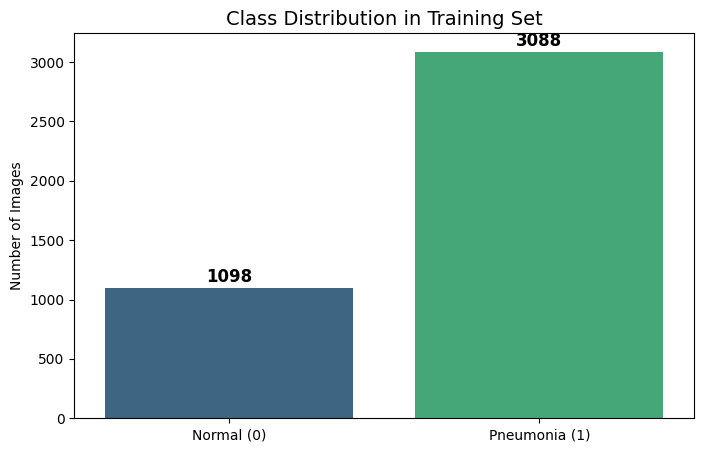

Total images: 4186
Imbalance Ratio (Normal/Pneumonia): 0.36


In [ ]:

# Extract labels from the training dataset
y_train = np.concatenate([y.numpy().flatten() for _, y in train_ds], axis=0).astype(int)

# Count occurrences
unique, counts = np.unique(y_train, return_counts=True)
class_counts = dict(zip(unique, counts))

# Plotting
plt.figure(figsize=(8, 5))
sns.barplot(x=["Normal (0)", "Pneumonia (1)"], y=counts, palette="viridis")
plt.title("Class Distribution in Training Set", fontsize=14)
plt.ylabel("Number of Images")
for i, count in enumerate(counts):
    plt.text(i, count + 50, str(count), ha='center', fontsize=12, fontweight='bold')
plt.show()

print(f"Total images: {len(y_train)}")
print(f"Imbalance Ratio (Normal/Pneumonia): {counts[0]/counts[1]:.2f}")

**Visualisation of samples from Datasets**

Visual check of the dataset operation is helpful to asses possible problems with the preprocessing operations. We defined image dimentions as a 128x128 pixels, and divided them into batches of 16.

Batch immages shape: (16, 128, 128, 3)
Batch labels shape: (16, 1)
First 10 labels in batch: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


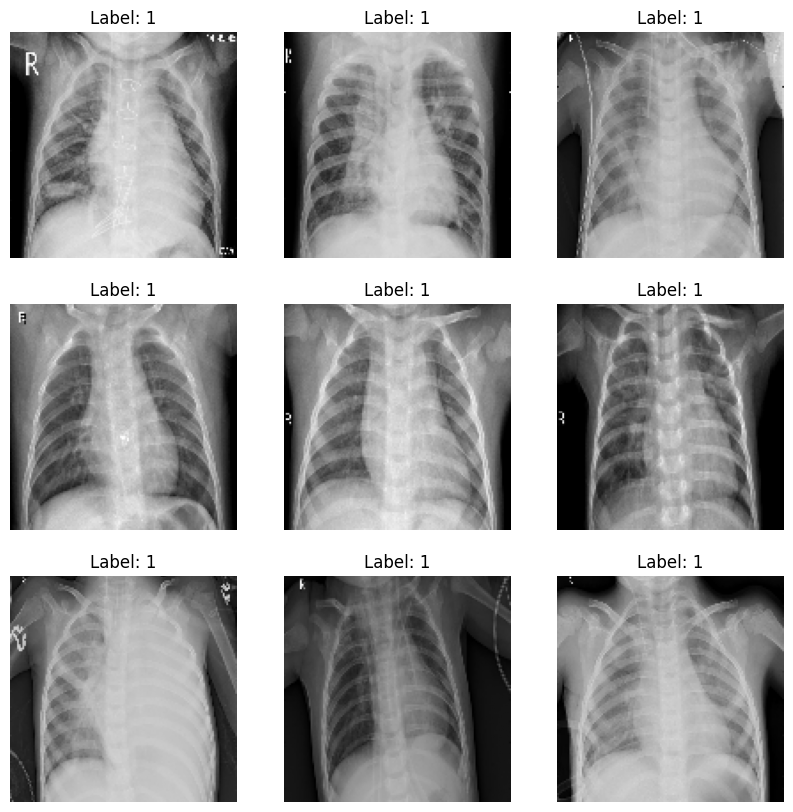

In [ ]:

# Batch from train set
for images, labels in train_ds.take(1):
    print("Batch immages shape:", images.shape)
    print("Batch labels shape:", labels.shape)
    print("First 10 labels in batch:", labels[:10].numpy().flatten())

    # Show first 9 images from batch
    plt.figure(figsize=(10,10))
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        img = images[i].numpy().astype("float32")[:,:,0]
        plt.imshow(img, cmap='gray')
        plt.title("Label: {}".format(int(labels[i].numpy()[0])))
        plt.axis("off")
    plt.show()
    break  # only for the first one


# **MODEL DEFINITION**

## **1. Regularization**

We apply L2 Regularization with a factor of 0.001 to our convolutional and dense layers, to discourage the model from learning overly complex patterns that might only exist in the training set (overfitting).

## **2. FE Module (Feature Extraction)**

Split-Channels strategy is used to improve efficiency.
1. One portion of the signal follows an "Identity" shortcut.
2. The other portion is processed via a Depthwise Convolution, which drastically reduces the number of parameters compared to standard convolutions.
3. The Residual Connection (Add) ensures stable gradient flow, preventing degradation as the model gets deeper.

## **3.MF Module (Multi-Feature Fusion)**

The MF Module is designed to capture patterns at various spatial scales using Dilated Convolutions with different dilation rates (1, 2, and 4).
This allows the model to learn both localized textures (small inflammatory spots) and larger pulmonary structures simultaneously, expanding the receptive field without losing spatial resolution.


In [ ]:

# REGULARIZATION
l2 = regularizers.l2(0.001)

# ======================
# FE MODULE
# ======================
def FE_module(x, out_channels):

  # shortcut implementation
    shortcut = layers.Conv2D(out_channels, 1, padding="same", kernel_regularizer=l2)(x)

    x = layers.Conv2D(out_channels, 1, padding="same", use_bias=False, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    split_point = out_channels // 4
    x1 = x[..., :split_point]
    x2 = x[..., split_point:]

    # depthwise_regularizer

    x2 = layers.DepthwiseConv2D(3, padding="same", use_bias=False, depthwise_regularizer=l2)(x2)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)

    x = layers.Concatenate()([x1, x2])
    x = layers.Add()([shortcut, x])
    x = layers.ReLU()(x)
    return x

# ======================
# MF MODULE
# ======================

def MF_module(input_tensor, out_channels):
    branches = []
    for dilation in [1, 2, 4]:
        # depthwise_regularizer
        b = layers.DepthwiseConv2D(3, dilation_rate=dilation, padding="same", use_bias=False, depthwise_regularizer=l2)(input_tensor)
        b = layers.BatchNormalization()(b)
        b = layers.ReLU()(b)
        branches.append(b)

    x = layers.Concatenate()(branches)
    x = layers.Conv2D(out_channels, 1, padding="same", use_bias=False, kernel_regularizer=l2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

# ======================
# MODEL CONSTRUCTION
# ======================

def build_model(input_shape=(128, 128, 3)):
    inputs = layers.Input(shape=input_shape)
    # data augmentation
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.05)(x)

    x = layers.Conv2D(32, 3, strides=2, padding="same", kernel_regularizer=l2)(x)
    x = FE_module(x, 64)
    x = layers.MaxPooling2D(2)(x)
    x = MF_module(x, 96)
    x = layers.MaxPooling2D(2)(x)
    x = FE_module(x, 128)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(96, activation="relu", kernel_regularizer=l2)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    return models.Model(inputs, outputs)




## **IMPORTANT IMPLEMENTATIONS**

1. **Label Smoothing (0.1)**: Softens the target labels to prevent the model from becoming "overconfident," which improves robustness.

2. **Dropout (0.5)**: Randomly deactivates neurons in the final classifier to force the network to learn redundant, reliable features.

3. **Callbacks & Learning Rate Scheduling**
We use **ReduceLROnPlateau** to automatically decrease the Learning Rate when the val_loss plateaus. This allows the model to "fine-tune" its weights in the final stages of training. EarlyStopping ensures we halt training once the model stops improving, saving time and preventing overfitting.

4. **Manual weight adjustment**
weights are maually assign to better fine-tune the performance of the model and fight class imbalance.

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# COSTRUCTION E COMPILATION
model = build_model()
#Label smooting
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# CLASS WEIGHTS (MANUAL)
class_weights = {0: 2.0, 1: 1.0}

# CALLBACKS
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=12, # Higher patient for scheduler
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# TRAINING
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=[early_stop, lr_scheduler]
)

# EVALUATION

y_true = np.concatenate([y for x, y in test_ds], axis=0).flatten()
y_pred_probs = model.predict(test_ds)

# threshold of  0.6. (we could try 0.7-0.8)

threshold = 0.6
y_pred = (y_pred_probs > threshold).astype(int).flatten()
print("\n--- FINAL REPORT ---")
print(classification_report(y_true, y_pred))

# Model save
save_path = "/content/drive/MyDrive/chest_xray_model_final.keras"
model.save(save_path)
print(f"Model saved successfully at: {save_path}")

Epoch 1/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 68s 208ms/step - accuracy: 0.8046 - auc: 0.8765 - loss: 1.0906 - val_accuracy: 0.7600 - val_auc: 0.5481 - val_loss: 1.3316 - learning_rate: 0.0010
Epoch 2/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 52s 196ms/step - accuracy: 0.9104 - auc: 0.9610 - loss: 0.7355 - val_accuracy: 0.7763 - val_auc: 0.9725 - val_loss: 0.7054 - learning_rate: 0.0010
Epoch 3/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 82s 196ms/step - accuracy: 0.9313 - auc: 0.9770 - loss: 0.6098 - val_accuracy: 0.9388 - val_auc: 0.9842 - val_loss: 0.4634 - learning_rate: 0.0010
Epoch 4/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 52s 200ms/step - accuracy: 0.9397 - auc: 0.9780 - loss: 0.5587 - val_accuracy: 0.8805 - val_auc: 0.9938 - val_loss: 0.4821 - learning_rate: 0.0010
Epoch 5/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 51s 193ms/step - accuracy: 0.9366 - auc: 0.9762 - loss: 0.5354 - val_accuracy: 0.7725 - val_auc: 0.9761 - val_loss: 0.7358 - learning_rate: 0.0010
Epoch 6/50
262/262 ━━━━━━━━━━━━━━━━━━━━ 53s 203ms/step - accuracy

## **ADVANCE MODEL EVALUATION**

1. **Training History:** We monitor the divergence between training and validation curves. A narrowing gap indicates effective L2 regularization and dropout.

2. **Confusion Matrix:** Essential for medical diagnosis. It helps us visualize False Negatives (missed cases), which are critical in pneumonia detection.

3. **ROC-AUC Curve:** The Area Under the Curve (AUC) represents the model's ability to correctly rank a random positive sample higher than a random negative one. A value closer to 1.0 indicates excellent discriminative power.


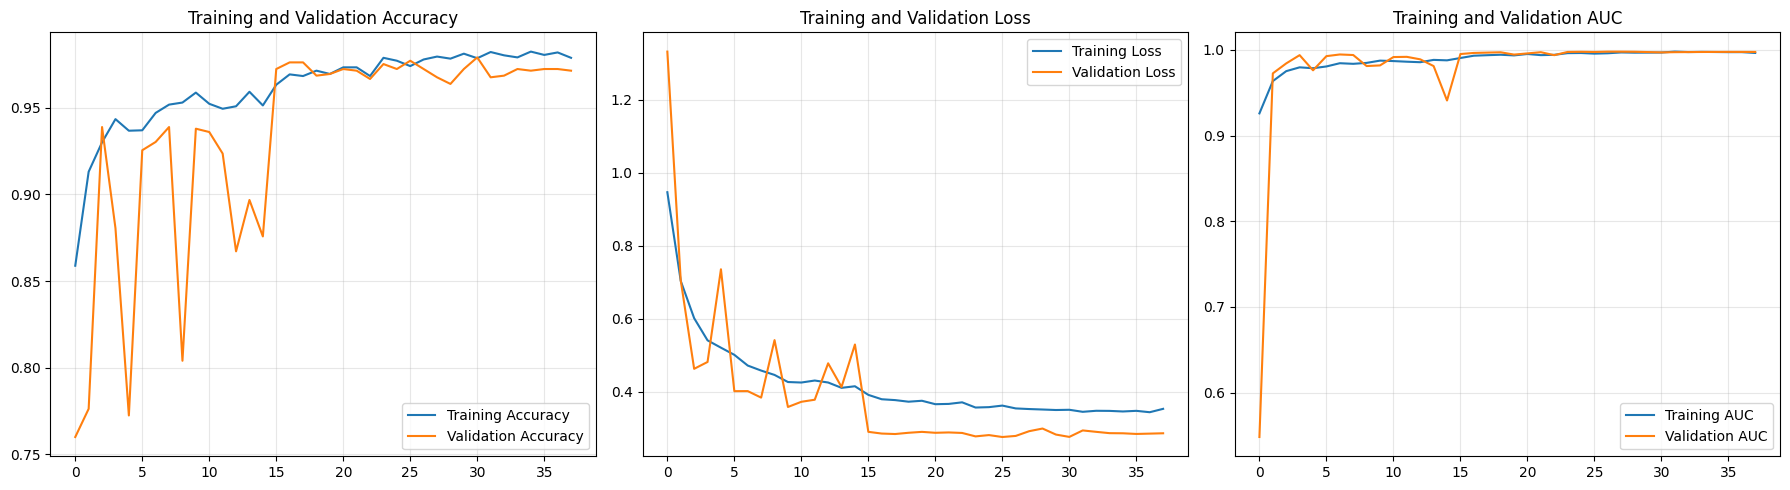

In [ ]:
def plot_training_history(history):

    # Metrics for evaluations
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    auc = history.history['auc']
    val_auc = history.history['val_auc']
    epochs_range = range(len(acc))

    plt.figure(figsize=(18, 5))

    # Plot Accuracy
    plt.subplot(1, 3, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Plot Loss
    plt.subplot(1, 3, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # Plot AUC
    plt.subplot(1, 3, 3)
    plt.plot(epochs_range, auc, label='Training AUC')
    plt.plot(epochs_range, val_auc, label='Validation AUC')
    plt.title('Training and Validation AUC')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history)

39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 170ms/step


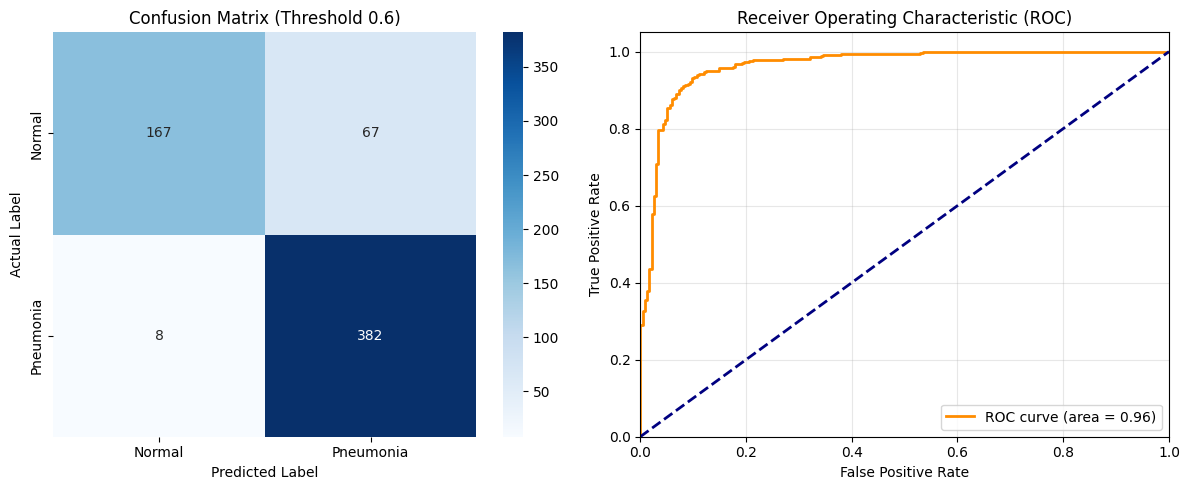

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import seaborn as sns

def plot_advanced_evaluation(model, test_ds):
    # Predictions and real values
    y_true = np.concatenate([y for x, y in test_ds], axis=0).flatten()
    y_pred_probs = model.predict(test_ds).flatten()
    y_pred = (y_pred_probs > 0.6).astype(int) # using 0.6

    # CONFUSION MATRIX
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Pneumonia'],
                yticklabels=['Normal', 'Pneumonia'])
    plt.title('Confusion Matrix (Threshold 0.6)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')

    # ROC CURVE
    fpr, tpr, _ = roc_curve(y_true, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_advanced_evaluation(model, test_ds)